In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../datasets/hotel_bookings_clean.csv")
df.shape

Matplotlib is building the font cache; this may take a moment.


(87226, 32)

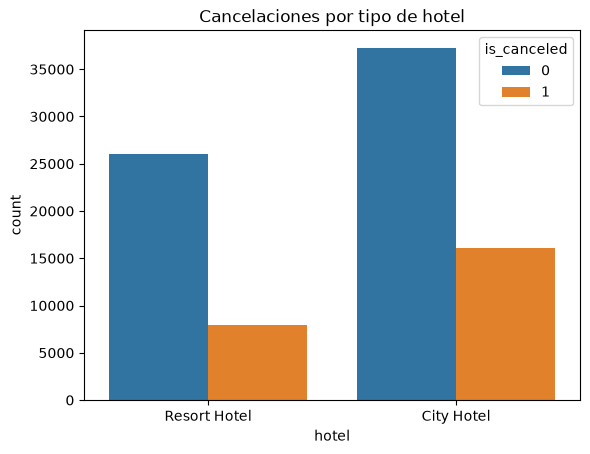

In [2]:
sns.countplot(data=df, x="hotel", hue="is_canceled")
plt.title("Cancelaciones por tipo de hotel")
plt.show()

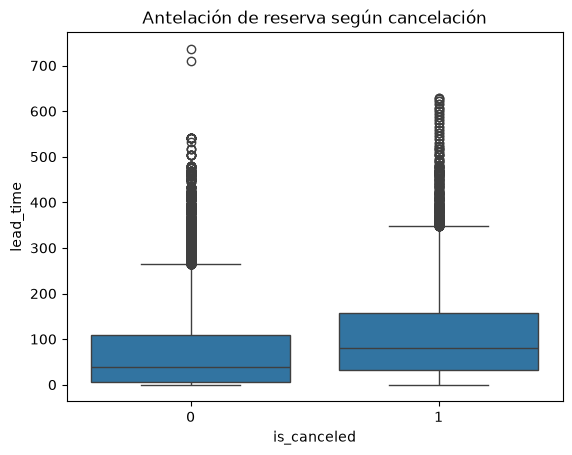

In [3]:
sns.boxplot(data=df, x="is_canceled", y="lead_time")
plt.title("Antelación de reserva según cancelación")
plt.show()

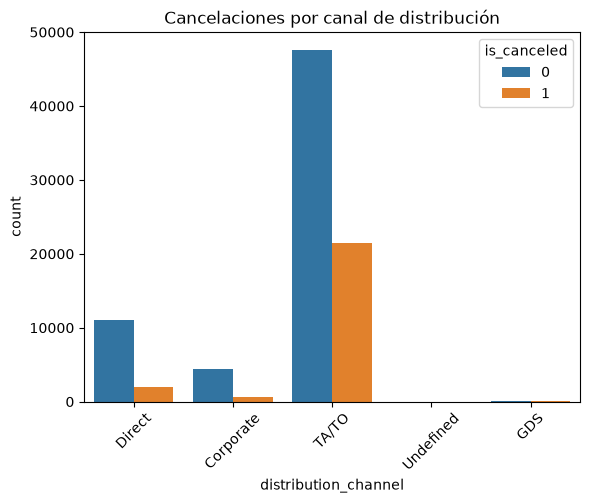

In [4]:
sns.countplot(data=df, x="distribution_channel", hue="is_canceled")
plt.title("Cancelaciones por canal de distribución")
plt.xticks(rotation=45)
plt.show()

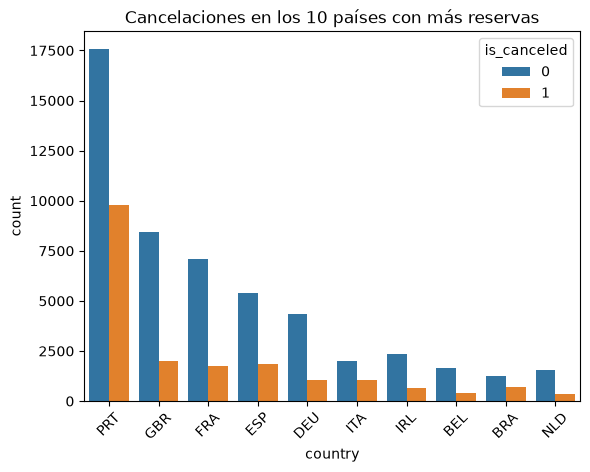

In [5]:
top_countries = df["country"].value_counts().head(10).index

df_top_countries = df[df["country"].isin(top_countries)]

sns.countplot(data=df_top_countries, x="country", hue="is_canceled",
              order=top_countries)
plt.title("Cancelaciones en los 10 países con más reservas")
plt.xticks(rotation=45)
plt.show()

In [6]:
df_top_countries.groupby("country")["is_canceled"].mean().loc[top_countries]

country
PRT    0.357647
GBR    0.190330
FRA    0.196305
ESP    0.257040
DEU    0.195543
ITA    0.351192
IRL    0.221559
BEL    0.197501
BRA    0.364777
NLD    0.183246
Name: is_canceled, dtype: float64

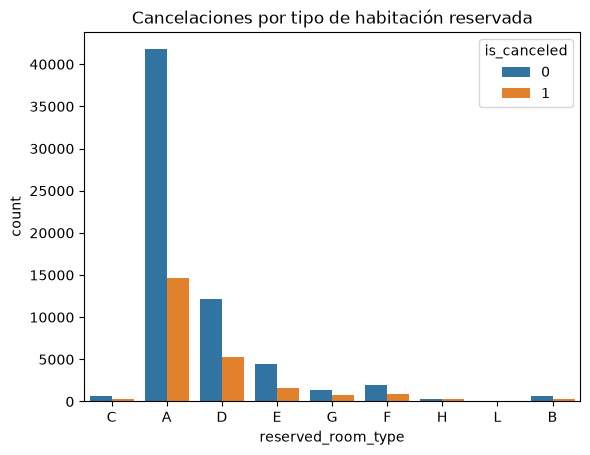

In [7]:
sns.countplot(data=df, x="reserved_room_type", hue="is_canceled")
plt.title("Cancelaciones por tipo de habitación reservada")
plt.show()

In [8]:
df.groupby("reserved_room_type")["is_canceled"].mean().sort_values(ascending=False)

reserved_room_type
H    0.407718
G    0.359512
L    0.333333
C    0.323851
B    0.318273
F    0.301773
D    0.301278
E    0.272697
A    0.260172
Name: is_canceled, dtype: float64

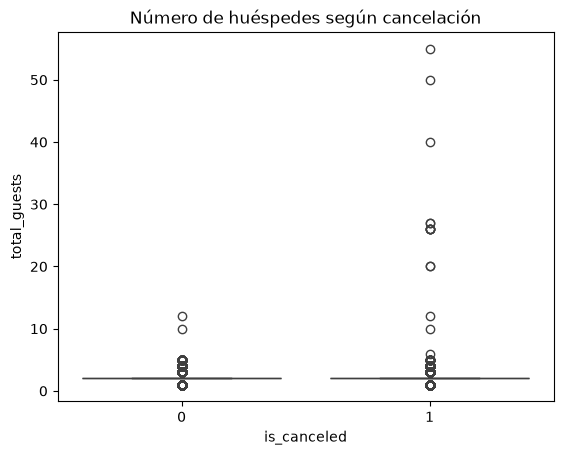

In [9]:
df["total_guests"] = df["adults"] + df["children"] + df["babies"]

sns.boxplot(data=df, x="is_canceled", y="total_guests")
plt.title("Número de huéspedes según cancelación")
plt.show()

In [10]:
df["total_guests"].describe()

count    87226.000000
mean         2.029154
std          0.790129
min          1.000000
25%          2.000000
50%          2.000000
75%          2.000000
max         55.000000
Name: total_guests, dtype: float64

In [11]:
df[df["total_guests"] > 10]

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,agent,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,has_company,total_guests
320,Resort Hotel,1,55,2015,July,29,12,4,10,2,...,8.0,0,Contract,133.16,0,1,No-Show,2015-07-12,0,12
1455,Resort Hotel,1,304,2015,September,36,3,0,3,40,...,0.0,0,Group,0.00,0,0,Canceled,2015-01-02,0,40
1503,Resort Hotel,1,333,2015,September,36,5,2,5,26,...,96.0,0,Group,0.00,0,0,Canceled,2015-01-02,0,26
1558,Resort Hotel,1,336,2015,September,37,7,1,2,50,...,0.0,0,Group,0.00,0,0,Canceled,2015-01-18,0,50
1664,Resort Hotel,1,340,2015,September,37,12,2,5,26,...,96.0,0,Group,0.00,0,0,Canceled,2015-01-02,0,26
1788,Resort Hotel,1,347,2015,September,38,19,2,5,26,...,96.0,0,Group,0.00,0,0,Canceled,2015-01-02,0,26
1816,Resort Hotel,1,349,2015,September,39,21,1,3,27,...,0.0,0,Group,0.00,0,0,Canceled,2015-01-02,0,27
1859,Resort Hotel,1,352,2015,September,39,24,1,3,27,...,0.0,0,Group,0.00,0,0,Canceled,2015-01-02,0,27
1897,Resort Hotel,1,354,2015,September,39,26,2,5,26,...,96.0,0,Group,0.00,0,0,Canceled,2015-01-02,0,26
2044,Resort Hotel,1,361,2015,October,40,3,2,5,26,...,96.0,0,Group,0.00,0,0,Canceled,2015-01-02,0,26


## Nota sobre outliers en número de huéspedes

Se detectaron 14 reservas con más de 10 huéspedes (hasta 55), de las cuales 13
correspondían a reservas canceladas. Dado que el 75% de las reservas tiene 2
huéspedes o menos, estos casos se consideran atípicos y no representativos del
comportamiento habitual de reserva (posiblemente reservas de grupo/evento con
dinámica de cancelación distinta, o errores de registro). Se eliminan del
dataset para evitar que distorsionen tanto el análisis exploratorio como el
modelo.

In [12]:
df = df[df["total_guests"] <= 10]
df.shape

(87212, 33)

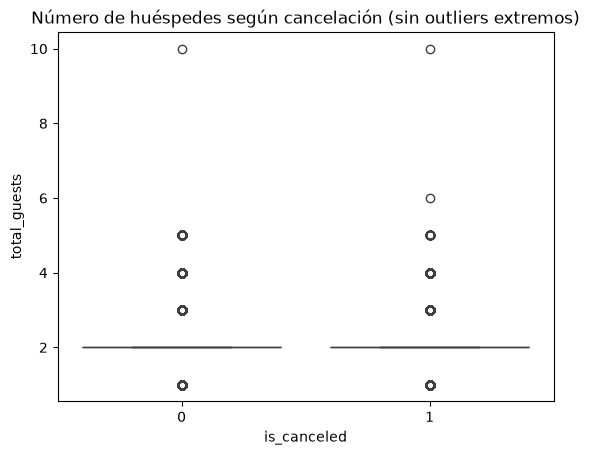

In [13]:
sns.boxplot(data=df, x="is_canceled", y="total_guests")
plt.title("Número de huéspedes según cancelación (sin outliers extremos)")
plt.show()

In [14]:
df.to_csv("../datasets/hotel_bookings_clean.csv", index=False)